# Advanced Preprocessing for Customer Segmentation

This notebook prepares the customer-level RFM and behavioural features for clustering. The main steps are checking the raw features, analysing distributions and outliers, applying log transformation, scaling the variables and validating the final output.


## Phase 1: Setup and initial validation



### 1: Import the required libraries




In [1]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_style("whitegrid")


###  2: Define the file paths




In [2]:
input_file = "/content/customer_features_ready_for_preprocessing.csv"

results_dir = "/content/Advanced_Preprocessing_Results"

data_dir = os.path.join(results_dir, "Data")
tables_dir = os.path.join(results_dir, "Tables")
figures_dir = os.path.join(results_dir, "Figures")
models_dir = os.path.join(results_dir, "Models")

for folder in [
    results_dir,
    data_dir,
    tables_dir,
    figures_dir,
    models_dir
]:
    os.makedirs(folder, exist_ok=True)

print("=" * 80)
print("ADVANCED PREPROCESSING PIPELINE")
print("=" * 80)


ADVANCED PREPROCESSING PIPELINE


###  3: Load the customer feature dataset




In [3]:
customer_features_original = pd.read_csv(input_file)

customer_features = customer_features_original.copy()

print("\nDataset loaded successfully.")

print("\nOriginal dataset shape:")
print(customer_features.shape)

print("\nOriginal columns:")
print(customer_features.columns.tolist())

print("\nFirst five rows:")
display(customer_features.head())

print("\nDataset information:")
customer_features.info()



Dataset loaded successfully.

Original dataset shape:
(4338, 9)

Original columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'ProductDiversity', 'TransactionCount', 'AverageOrderValue', 'BasketSize']

First five rows:


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,326,1,"77,183.6000",74215,1,1,"77,183.6000","74,215.0000"
1,12347,2,7,"4,310.0000",2458,103,182,615.7100,351.1400
2,12348,75,4,"1,797.2400",2341,22,31,449.3100,585.2500
3,12349,19,1,"1,757.5500",631,73,73,"1,757.5500",631.0000
4,12350,310,1,334.4000,197,17,17,334.4000,197.0000



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         4338 non-null   int64  
 1   Recency            4338 non-null   int64  
 2   Frequency          4338 non-null   int64  
 3   Monetary           4338 non-null   float64
 4   TotalQuantity      4338 non-null   int64  
 5   ProductDiversity   4338 non-null   int64  
 6   TransactionCount   4338 non-null   int64  
 7   AverageOrderValue  4338 non-null   float64
 8   BasketSize         4338 non-null   float64
dtypes: float64(3), int64(6)
memory usage: 305.1 KB


### 4: Select the clustering features




In [4]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

required_columns = [
    "CustomerID"
] + feature_columns


###  5: Remove unused columns and order the dataset


In [5]:
unexpected_columns = [
    column
    for column in customer_features.columns
    if column not in required_columns
]

print("\nUnexpected or unused columns found:")
print(unexpected_columns)

# Remove TransactionCount or any other unused columns
if unexpected_columns:
    customer_features = customer_features.drop(
        columns=unexpected_columns
    )

# Reorder the remaining columns to match required_columns
customer_features = customer_features[
    required_columns
].copy()

print("\nFinal selected columns:")
print(customer_features.columns.tolist())

print("\nFinal dataset shape:")
print(customer_features.shape)

# Confirm that the columns are correct
assert list(customer_features.columns) == required_columns

print("\nUnused columns removed and column order verified successfully.")



Unexpected or unused columns found:
['TransactionCount']

Final selected columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']

Final dataset shape:
(4338, 8)

Unused columns removed and column order verified successfully.


###  6: Validate the raw customer features



In [6]:
missing_required_columns = [
    column
    for column in required_columns
    if column not in customer_features.columns
]

if missing_required_columns:

    raise ValueError(
        f"Missing required columns: {missing_required_columns}"
    )

raw_validation_report = pd.DataFrame({
    "Validation Check": [
        "Total Customers",
        "Total Columns",
        "Missing Values",
        "Duplicate Customer IDs",
        "Invalid Customer IDs",
        "Recency <= 0",
        "Frequency <= 0",
        "Monetary <= 0",
        "AverageOrderValue <= 0",
        "BasketSize <= 0",
        "ProductDiversity <= 0",
        "TotalQuantity <= 0",
        "Infinite Values"
    ],

    "Result": [
        len(customer_features),
        customer_features.shape[1],
        customer_features.isnull().sum().sum(),
        customer_features["CustomerID"].duplicated().sum(),
        (customer_features["CustomerID"] <= 0).sum(),
        (customer_features["Recency"] <= 0).sum(),
        (customer_features["Frequency"] <= 0).sum(),
        (customer_features["Monetary"] <= 0).sum(),
        (customer_features["AverageOrderValue"] <= 0).sum(),
        (customer_features["BasketSize"] <= 0).sum(),
        (customer_features["ProductDiversity"] <= 0).sum(),
        (customer_features["TotalQuantity"] <= 0).sum(),
        np.isinf(
            customer_features[feature_columns].to_numpy()
        ).sum()
    ]
})

print("\nRaw feature validation report:")
display(raw_validation_report)

raw_validation_report.to_csv(
    os.path.join(
        tables_dir,
        "raw_feature_validation_report.csv"
    ),
    index=False
)

if customer_features.isnull().sum().sum() > 0:

    raise ValueError(
        "Missing values found in customer feature dataset."
    )

if customer_features["CustomerID"].duplicated().sum() > 0:

    raise ValueError(
        "Duplicate CustomerID values found."
    )

if not np.isfinite(
    customer_features[feature_columns].to_numpy()
).all():

    raise ValueError(
        "Infinite or invalid numerical values found."
    )



Raw feature validation report:


,Validation Check,Result
0,Total Customers,4338
1,Total Columns,8
2,Missing Values,0
3,Duplicate Customer IDs,0
4,Invalid Customer IDs,0
5,Recency <= 0,0
6,Frequency <= 0,0
7,Monetary <= 0,0
8,AverageOrderValue <= 0,0
9,BasketSize <= 0,0


###  7: Save the corrected raw dataset




In [7]:
customer_features.to_csv(
    os.path.join(
        data_dir,
        "customer_features_raw_corrected.csv"
    ),
    index=False
)

print("\nCorrected raw feature dataset saved successfully.")



Corrected raw feature dataset saved successfully.


## Phase 2: Explore the raw feature distributions




###  8: Review descriptive statistics




In [8]:
descriptive_statistics = (
    customer_features[feature_columns]
    .describe()
    .T
)

descriptive_statistics["Median"] = (
    customer_features[feature_columns]
    .median()
)

descriptive_statistics["Variance"] = (
    customer_features[feature_columns]
    .var()
)

descriptive_statistics["IQR"] = (
    customer_features[feature_columns]
    .quantile(0.75)
    -
    customer_features[feature_columns]
    .quantile(0.25)
)

print("\nDescriptive statistics:")
display(descriptive_statistics)

descriptive_statistics.to_csv(
    os.path.join(
        tables_dir,
        "raw_feature_descriptive_statistics.csv"
    )
)



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max,Median,Variance,IQR
Recency,"4,338.0000",92.5364,100.0142,1.0000,18.0000,51.0000,142.0000,374.0000,51.0000,"10,002.8339",124.0000
Frequency,"4,338.0000",4.2720,7.6980,1.0000,1.0000,2.0000,5.0000,209.0000,2.0000,59.2592,4.0000
Monetary,"4,338.0000","2,048.6881","8,985.2302",3.7500,306.4825,668.5700,"1,660.5975","280,206.0200",668.5700,"80,734,362.1066","1,354.1150"
AverageOrderValue,"4,338.0000",417.6457,"1,796.5113",3.4500,177.8625,291.9400,428.2800,"84,236.2500",291.9400,"3,227,453.0043",250.4175
BasketSize,"4,338.0000",252.4629,"1,312.7693",1.0000,92.0000,161.0000,270.0000,"74,215.0000",161.0000,"1,723,363.3184",178.0000
ProductDiversity,"4,338.0000",61.5012,85.3668,1.0000,16.0000,35.0000,77.0000,"1,787.0000",35.0000,"7,287.4850",61.0000
TotalQuantity,"4,338.0000","1,187.6445","5,043.6197",1.0000,159.0000,378.0000,989.7500,"196,915.0000",378.0000,"25,438,099.2169",830.7500


###  9: Plot the original feature distributions




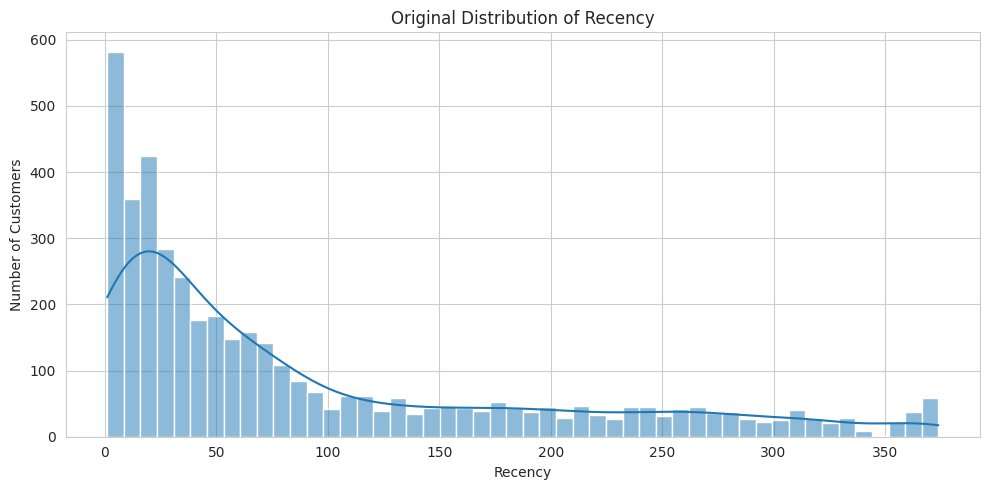

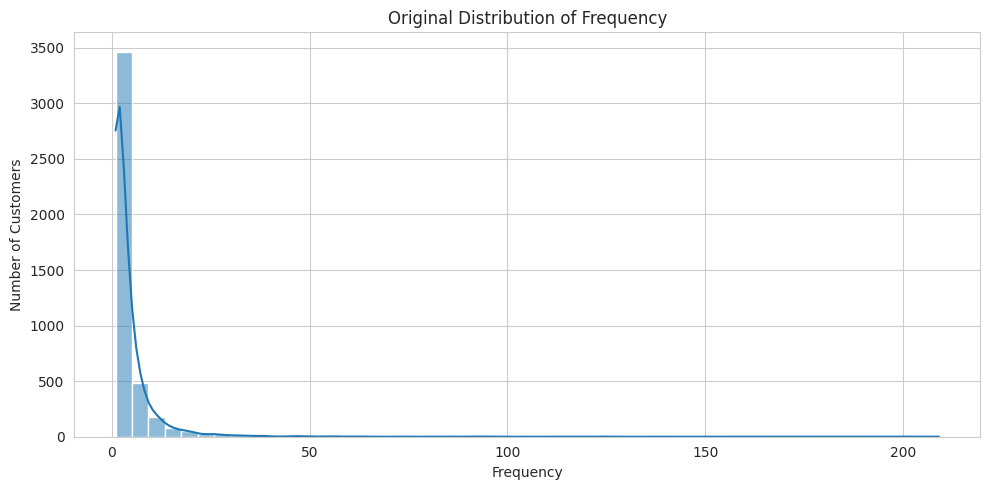

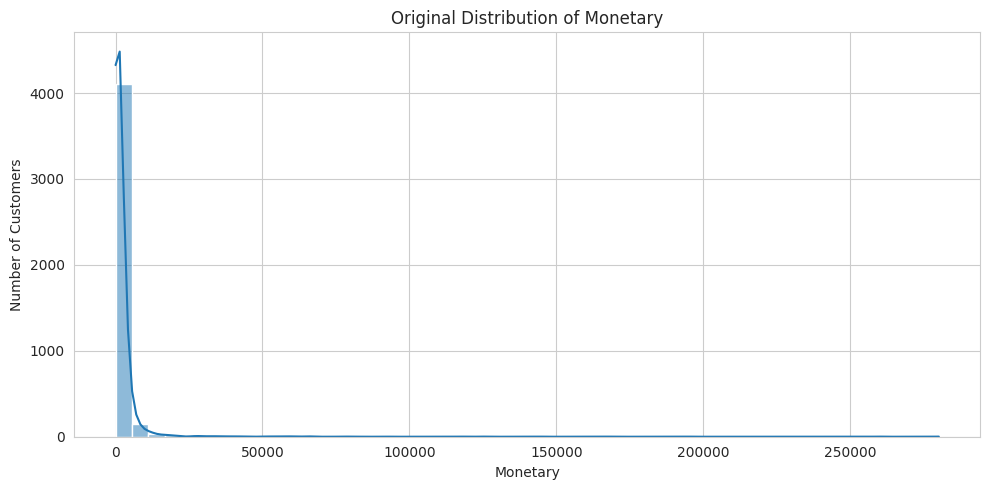

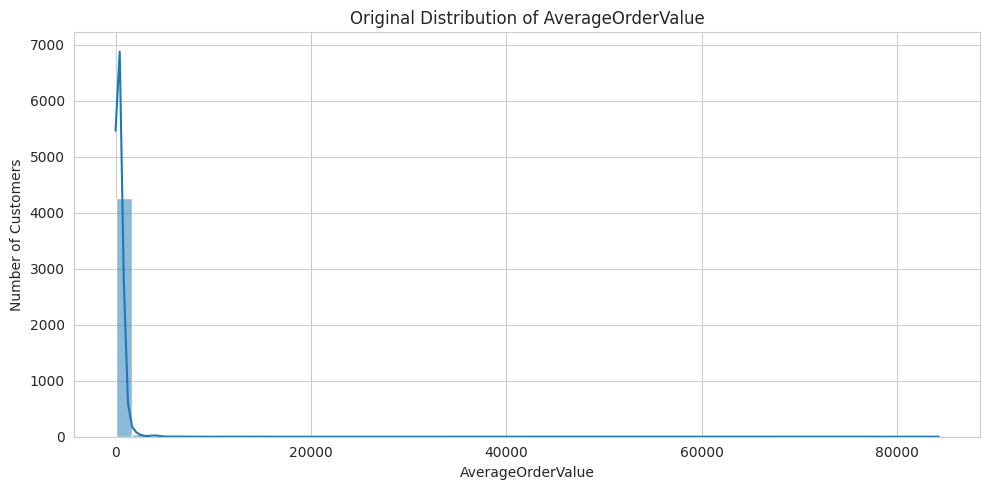

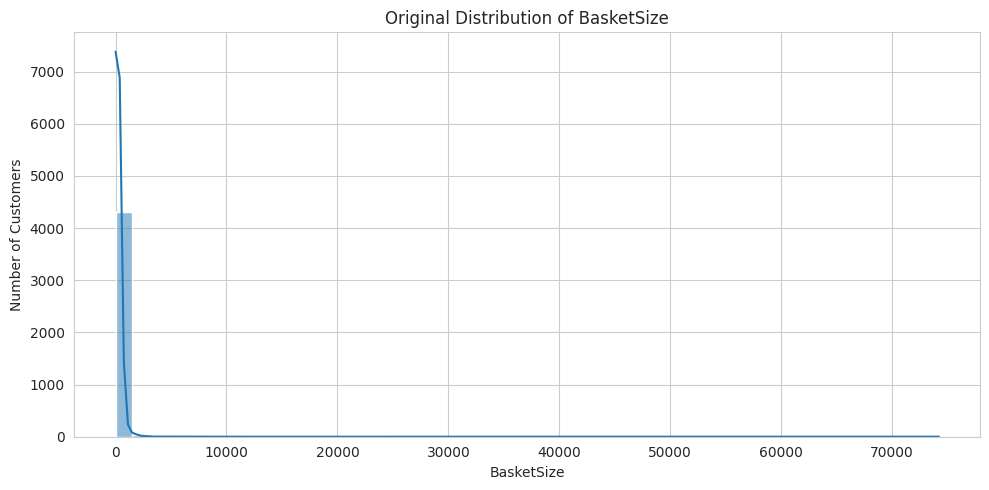

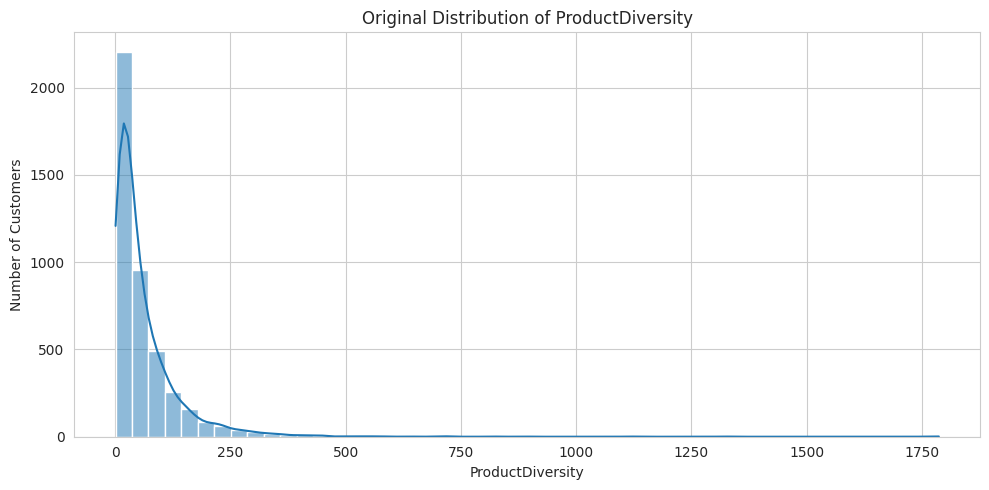

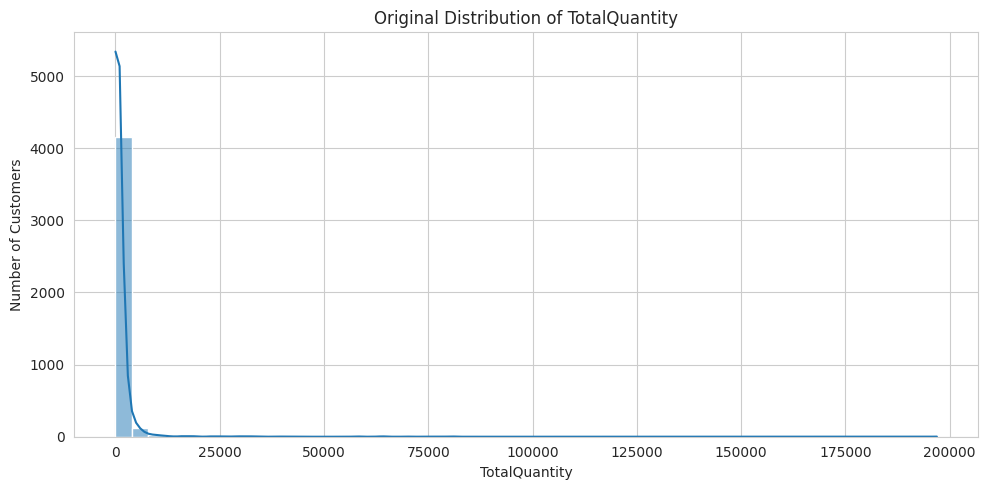

In [9]:
for feature in feature_columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        customer_features[feature],
        bins=50,
        kde=True
    )

    plt.title(
        f"Original Distribution of {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Customers")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            figures_dir,
            f"original_distribution_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


###  10: Plot boxplots before transformation




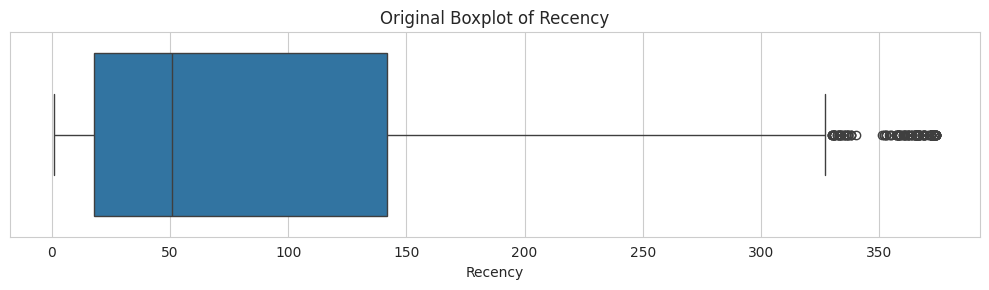

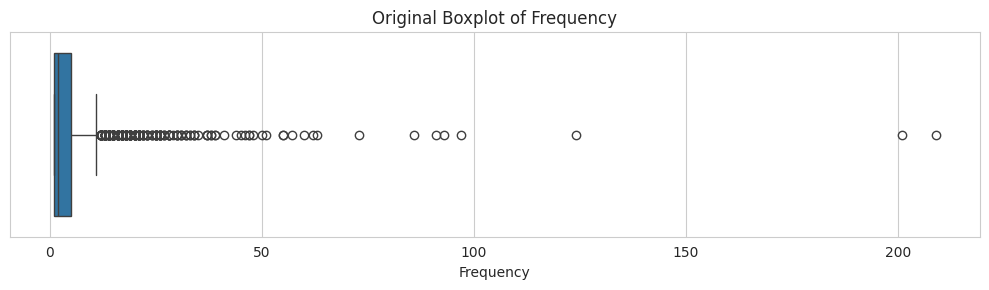

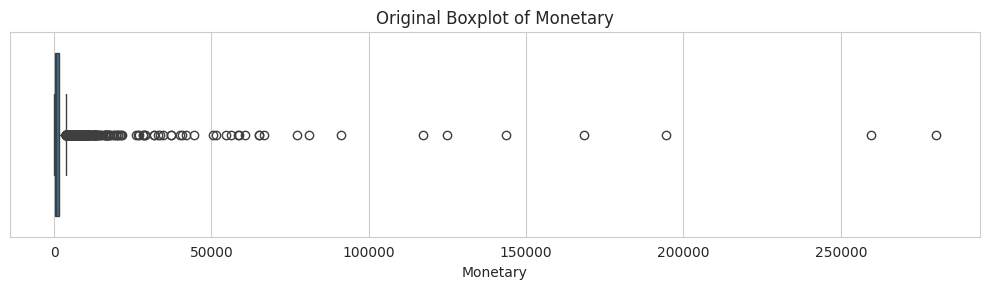

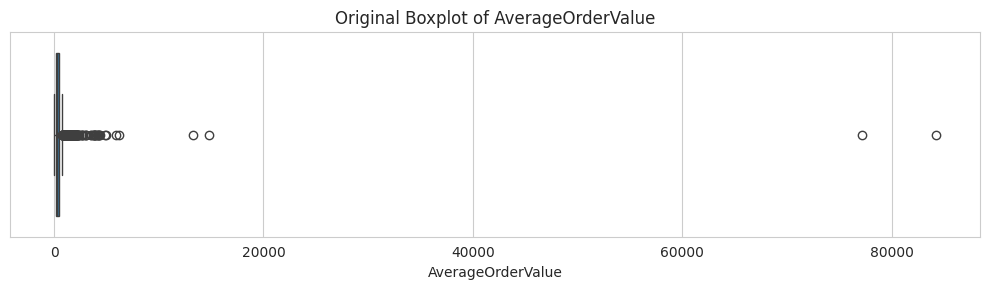

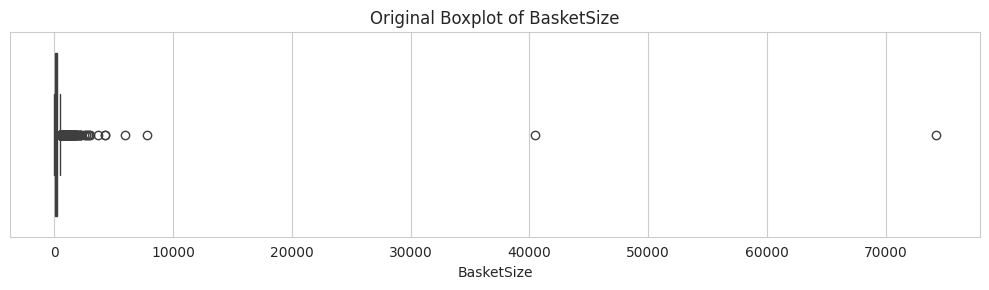

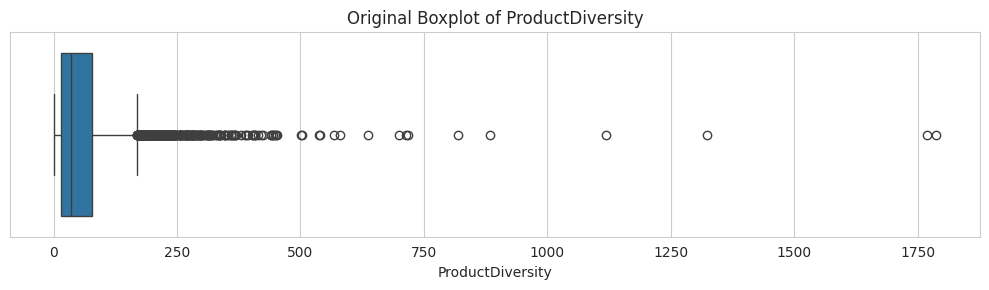

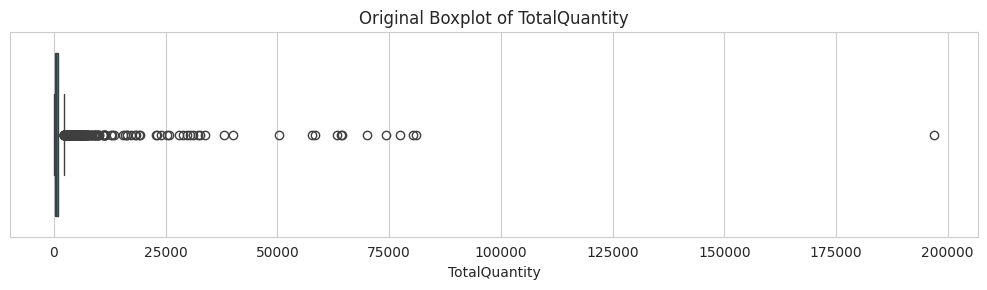

In [10]:
for feature in feature_columns:

    plt.figure(figsize=(10, 3))

    sns.boxplot(
        x=customer_features[feature]
    )

    plt.title(
        f"Original Boxplot of {feature}"
    )

    plt.xlabel(feature)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            figures_dir,
            f"original_boxplot_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


###  11: Measure skewness and kurtosis




In [11]:
distribution_report_before = pd.DataFrame({
    "Feature": feature_columns,

    "Skewness Before": [
        customer_features[feature].skew()
        for feature in feature_columns
    ],

    "Kurtosis Before": [
        customer_features[feature].kurtosis()
        for feature in feature_columns
    ]
})

print("\nSkewness and kurtosis before transformation:")
display(distribution_report_before)

distribution_report_before.to_csv(
    os.path.join(
        tables_dir,
        "distribution_report_before_transformation.csv"
    ),
    index=False
)



Skewness and kurtosis before transformation:


,Feature,Skewness Before,Kurtosis Before
0,Recency,1.2460,0.4306
1,Frequency,12.0670,249.0581
2,Monetary,19.3394,478.6843
3,AverageOrderValue,41.6924,"1,862.5712"
4,BasketSize,48.0082,"2,527.8996"
5,ProductDiversity,6.9194,99.7536
6,TotalQuantity,20.3840,609.9895


###  12: Analyse possible outliers using the IQR rule



In [12]:
outlier_results = []

for feature in feature_columns:

    q1 = customer_features[feature].quantile(0.25)

    q3 = customer_features[feature].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)

    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (
        (customer_features[feature] < lower_bound)
        |
        (customer_features[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    outlier_percentage = (
        outlier_count
        / len(customer_features)
        * 100
    )

    outlier_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": outlier_percentage
    })

outlier_report = pd.DataFrame(
    outlier_results
).round(4)

print("\nIQR outlier analysis:")
display(outlier_report)

outlier_report.to_csv(
    os.path.join(
        tables_dir,
        "iqr_outlier_analysis.csv"
    ),
    index=False
)

print(
    "\nOutliers are retained because they may represent "
    "genuine high-value or high-volume customers."
)



IQR outlier analysis:


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,Recency,18.0000,142.0000,124.0000,-168.0000,328.0000,155,3.5731
1,Frequency,1.0000,5.0000,4.0000,-5.0000,11.0000,285,6.5698
2,Monetary,306.4825,"1,660.5975","1,354.1150","-1,724.6900","3,691.7700",425,9.7971
3,AverageOrderValue,177.8625,428.2800,250.4175,-197.7638,803.9062,291,6.7082
4,BasketSize,92.0000,270.0000,178.0000,-175.0000,537.0000,264,6.0858
5,ProductDiversity,16.0000,77.0000,61.0000,-75.5000,168.5000,309,7.1231
6,TotalQuantity,159.0000,989.7500,830.7500,"-1,087.1250","2,235.8750",401,9.2439



Outliers are retained because they may represent genuine high-value or high-volume customers.


###  13: Check raw feature variance

In [13]:
raw_variance_report = pd.DataFrame({
    "Feature": feature_columns,

    "Variance": [
        customer_features[feature].var()
        for feature in feature_columns
    ],

    "Unique Values": [
        customer_features[feature].nunique()
        for feature in feature_columns
    ],

    "Constant Feature": [
        customer_features[feature].nunique() <= 1
        for feature in feature_columns
    ]
})

print("\nRaw feature variance report:")
display(raw_variance_report)

raw_variance_report.to_csv(
    os.path.join(
        tables_dir,
        "raw_feature_variance_report.csv"
    ),
    index=False
)

constant_features = raw_variance_report.loc[
    raw_variance_report["Constant Feature"],
    "Feature"
].tolist()

if constant_features:

    raise ValueError(
        f"Constant features detected: {constant_features}"
    )



Raw feature variance report:


,Feature,Variance,Unique Values,Constant Feature
0,Recency,"10,002.8339",349,False
1,Frequency,59.2592,59,False
2,Monetary,"80,734,362.1066",4246,False
3,AverageOrderValue,"3,227,453.0043",4147,False
4,BasketSize,"1,723,363.3184",2129,False
5,ProductDiversity,"7,287.4850",338,False
6,TotalQuantity,"25,438,099.2169",1749,False


###  14: Calculate the raw correlation matrix




Raw feature correlation matrix:


,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
Recency,1.0000,-0.2606,-0.1218,-0.0001,0.0074,-0.3007,-0.1234
Frequency,-0.2606,1.0000,0.5528,0.0191,0.0108,0.6922,0.5572
Monetary,-0.1218,0.5528,1.0000,0.3937,0.3105,0.3858,0.9229
AverageOrderValue,-0.0001,0.0191,0.3937,1.0000,0.9309,0.0360,0.4066
BasketSize,0.0074,0.0108,0.3105,0.9309,1.0000,0.0248,0.3841
ProductDiversity,-0.3007,0.6922,0.3858,0.0360,0.0248,1.0000,0.4088
TotalQuantity,-0.1234,0.5572,0.9229,0.4066,0.3841,0.4088,1.0000


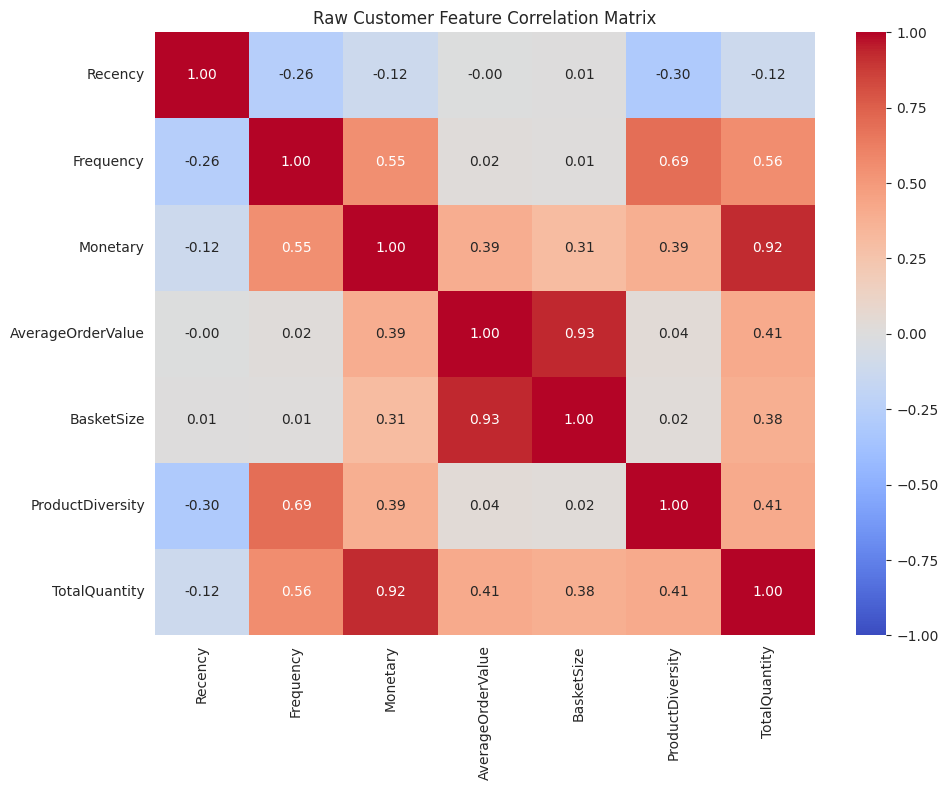

In [14]:
raw_correlation_matrix = (
    customer_features[feature_columns]
    .corr(method="pearson")
)

print("\nRaw feature correlation matrix:")
display(raw_correlation_matrix)

raw_correlation_matrix.to_csv(
    os.path.join(
        tables_dir,
        "raw_feature_correlation_matrix.csv"
    )
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    raw_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title(
    "Raw Customer Feature Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "raw_feature_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  15: Report highly correlated feature pairs



In [15]:
correlation_threshold = 0.90

high_correlation_pairs = []

for first_index in range(
    len(feature_columns)
):

    for second_index in range(
        first_index + 1,
        len(feature_columns)
    ):

        first_feature = feature_columns[
            first_index
        ]

        second_feature = feature_columns[
            second_index
        ]

        correlation_value = (
            raw_correlation_matrix.loc[
                first_feature,
                second_feature
            ]
        )

        if abs(correlation_value) >= correlation_threshold:

            high_correlation_pairs.append({
                "Feature 1": first_feature,
                "Feature 2": second_feature,
                "Correlation": correlation_value,
                "Absolute Correlation":
                    abs(correlation_value)
            })

high_correlation_report = pd.DataFrame(
    high_correlation_pairs
)

if high_correlation_report.empty:

    high_correlation_report = pd.DataFrame({
        "Feature 1": [],
        "Feature 2": [],
        "Correlation": [],
        "Absolute Correlation": []
    })

print(
    f"\nFeature pairs with absolute correlation "
    f">= {correlation_threshold}:"
)

display(high_correlation_report)

high_correlation_report.to_csv(
    os.path.join(
        tables_dir,
        "high_correlation_feature_pairs.csv"
    ),
    index=False
)



Feature pairs with absolute correlation >= 0.9:


,Feature 1,Feature 2,Correlation,Absolute Correlation
0,Monetary,TotalQuantity,0.9229,0.9229
1,AverageOrderValue,BasketSize,0.9309,0.9309


## Phase 3: Transform the skewed variables




###  16: Choose features for log transformation




In [16]:
log_features = [
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

non_log_features = [
    "Recency"
]

print("\nFeatures selected for log1p transformation:")
print(log_features)

print("\nFeatures not log transformed:")
print(non_log_features)



Features selected for log1p transformation:
['Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']

Features not log transformed:
['Recency']


###  17: Apply the log1p transformation




In [17]:
log_transformed_features = customer_features.copy()

for feature in log_features:

    log_transformed_features[feature] = np.log1p(
        log_transformed_features[feature]
    )

print("\nLog transformation completed.")

display(
    log_transformed_features.head()
)



Log transformation completed.


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,12346,326,0.6931,11.2540,11.2540,11.2147,0.6931,11.2147
1,12347,2,2.0794,8.3689,6.4244,5.8640,4.6444,7.8075
2,12348,75,1.6094,7.4946,6.1099,6.3737,3.1355,7.7588
3,12349,19,0.6931,7.4722,7.4722,6.4489,4.3041,6.4489
4,12350,310,0.6931,5.8153,5.8153,5.2883,2.8904,5.2883


###  18: Validate the transformed values




In [18]:
log_validation_report = pd.DataFrame({
    "Feature": feature_columns,

    "Missing Values": [
        log_transformed_features[feature]
        .isnull()
        .sum()
        for feature in feature_columns
    ],

    "Infinite Values": [
        np.isinf(
            log_transformed_features[feature]
        ).sum()
        for feature in feature_columns
    ],

    "Minimum": [
        log_transformed_features[feature].min()
        for feature in feature_columns
    ],

    "Maximum": [
        log_transformed_features[feature].max()
        for feature in feature_columns
    ]
})

print("\nLog transformation validation:")
display(log_validation_report)

log_validation_report.to_csv(
    os.path.join(
        tables_dir,
        "log_transformation_validation.csv"
    ),
    index=False
)

if not np.isfinite(
    log_transformed_features[feature_columns]
    .to_numpy()
).all():

    raise ValueError(
        "Invalid values detected after log transformation."
    )



Log transformation validation:


,Feature,Missing Values,Infinite Values,Minimum,Maximum
0,Recency,0,0,1.0000,374.0000
1,Frequency,0,0,0.6931,5.3471
2,Monetary,0,0,1.5581,12.5433
3,AverageOrderValue,0,0,1.4929,11.3414
4,BasketSize,0,0,0.6931,11.2147
5,ProductDiversity,0,0,0.6931,7.4889
6,TotalQuantity,0,0,0.6931,12.1905


###  19: Compare distributions before and after transformation




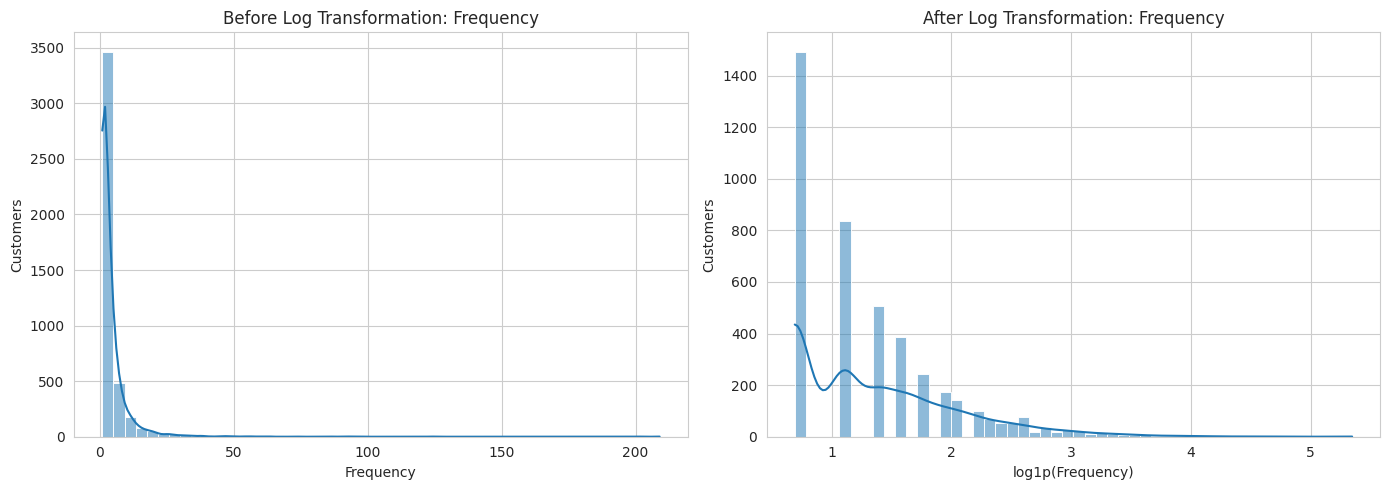

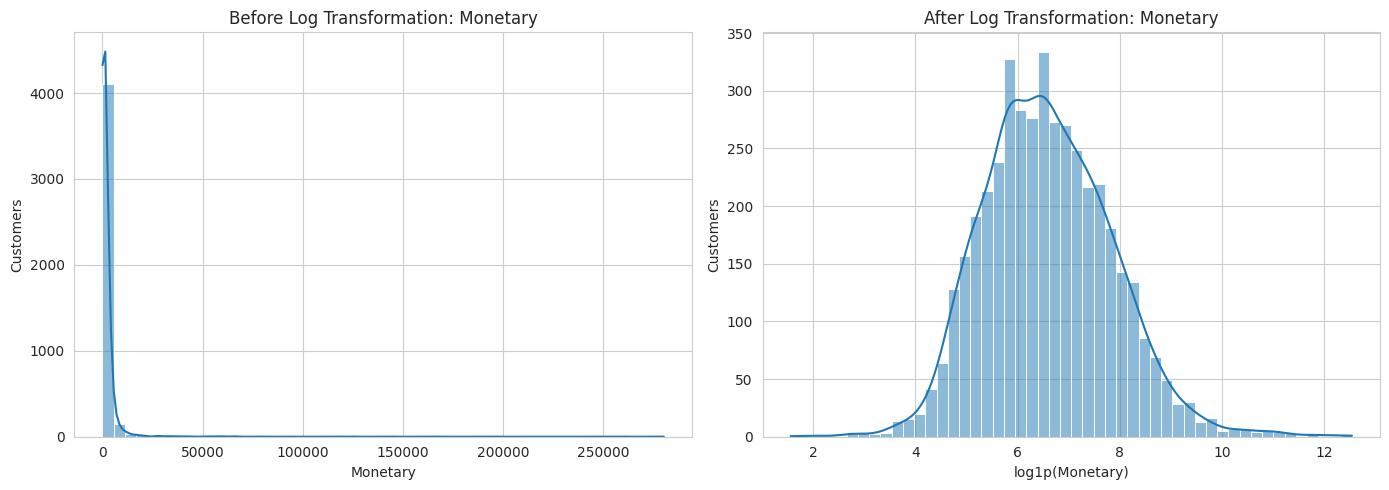

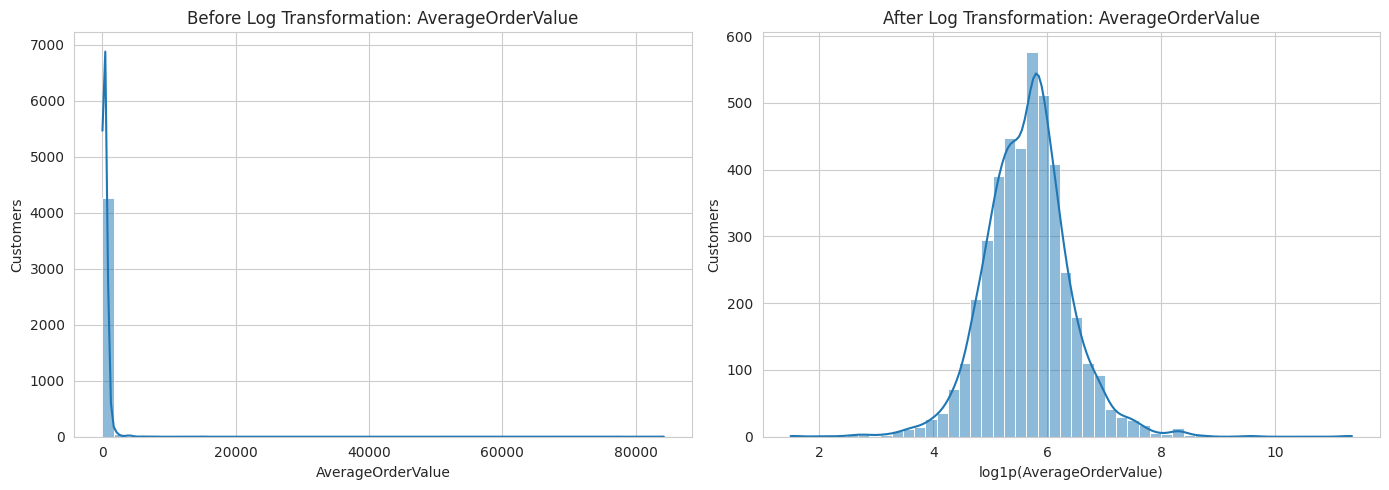

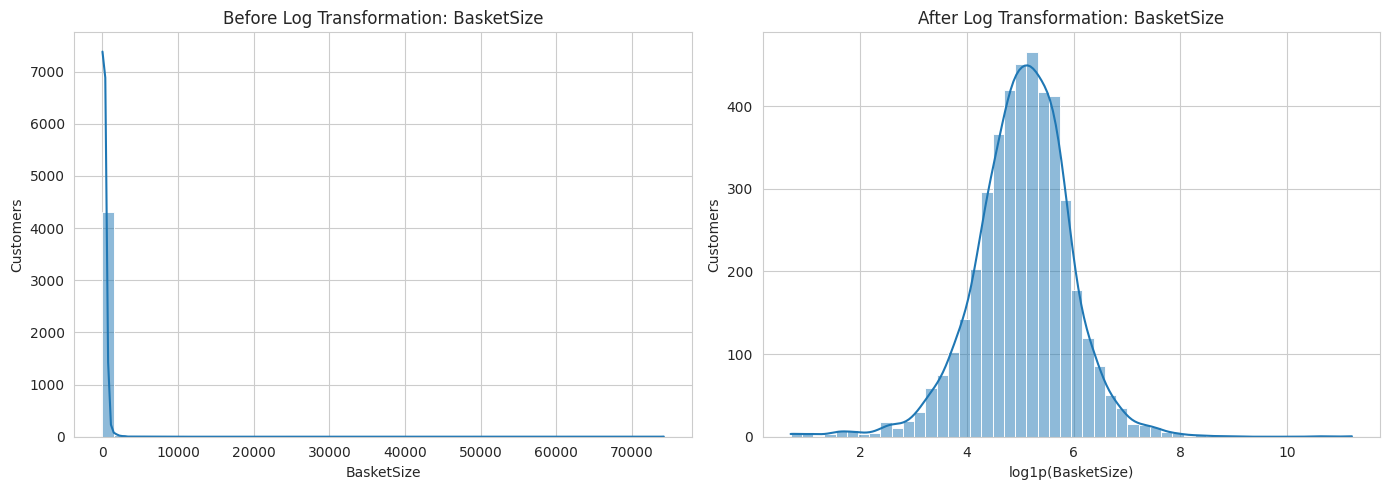

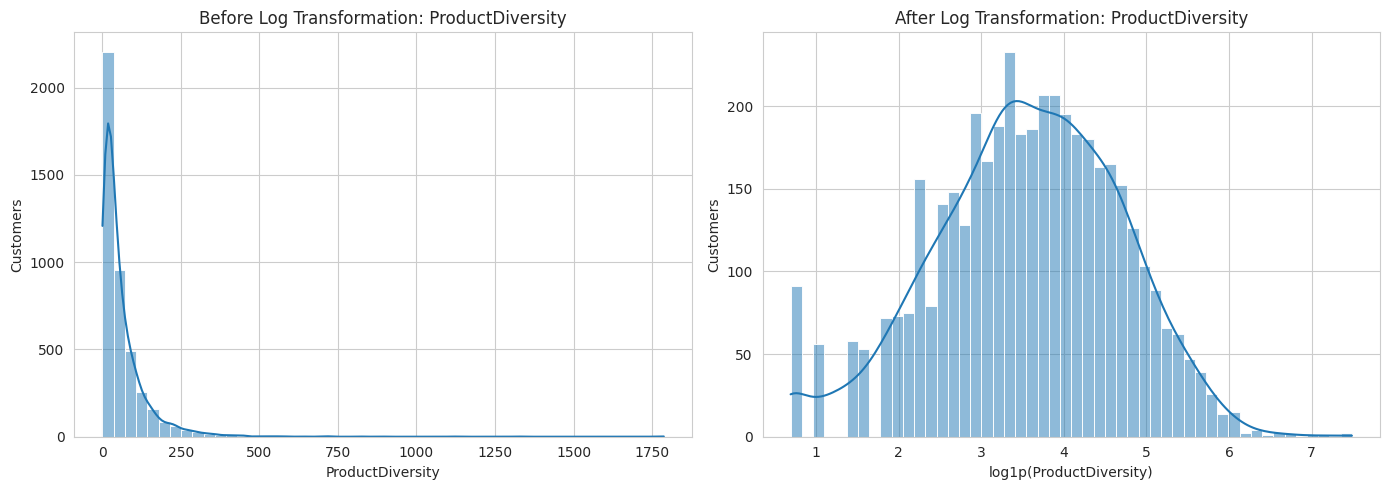

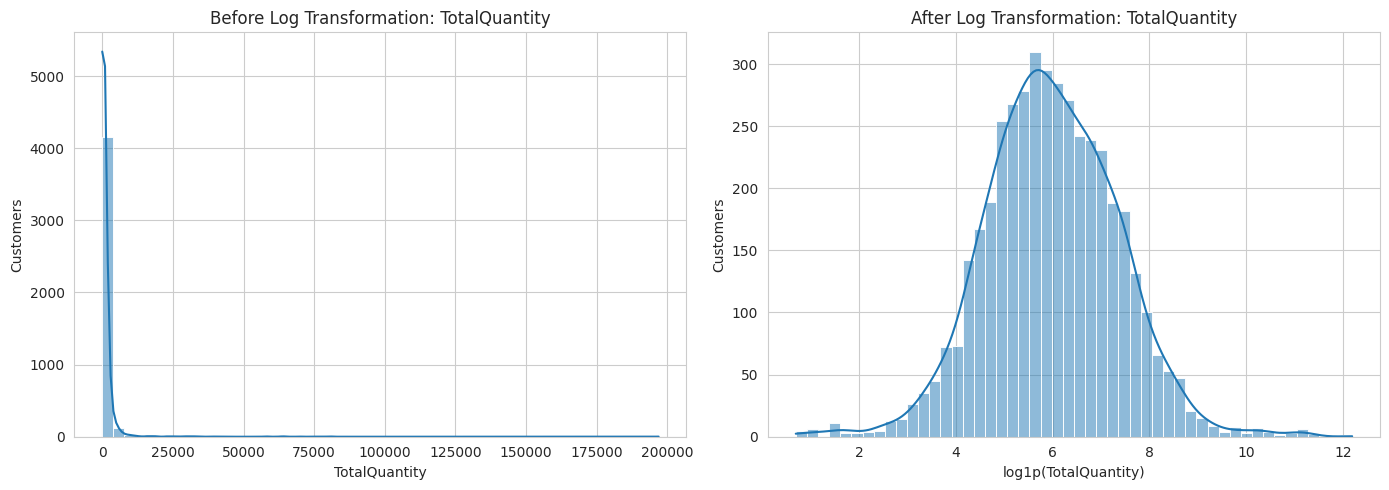

In [19]:
for feature in log_features:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    sns.histplot(
        customer_features[feature],
        bins=50,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(
        f"Before Log Transformation: {feature}"
    )

    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Customers")

    sns.histplot(
        log_transformed_features[feature],
        bins=50,
        kde=True,
        ax=axes[1]
    )

    axes[1].set_title(
        f"After Log Transformation: {feature}"
    )

    axes[1].set_xlabel(
        f"log1p({feature})"
    )

    axes[1].set_ylabel("Customers")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            figures_dir,
            f"before_after_log_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


###  20: Compare skewness and kurtosis after transformation



In [20]:
distribution_report_after = pd.DataFrame({
    "Feature": feature_columns,

    "Skewness After": [
        log_transformed_features[feature].skew()
        for feature in feature_columns
    ],

    "Kurtosis After": [
        log_transformed_features[feature].kurtosis()
        for feature in feature_columns
    ]
})

distribution_comparison = (
    distribution_report_before
    .merge(
        distribution_report_after,
        on="Feature",
        how="inner"
    )
)

distribution_comparison[
    "Absolute Skewness Reduction"
] = (
    distribution_comparison[
        "Skewness Before"
    ].abs()
    -
    distribution_comparison[
        "Skewness After"
    ].abs()
)

distribution_comparison = (
    distribution_comparison.round(4)
)

print("\nDistribution comparison:")
display(distribution_comparison)

distribution_comparison.to_csv(
    os.path.join(
        tables_dir,
        "distribution_before_after_comparison.csv"
    ),
    index=False
)



Distribution comparison:


,Feature,Skewness Before,Kurtosis Before,Skewness After,Kurtosis After,Absolute Skewness Reduction
0,Recency,1.2460,0.4306,1.2460,0.4306,0.0000
1,Frequency,12.0670,249.0581,1.2087,1.6837,10.8584
2,Monetary,19.3394,478.6843,0.3966,0.7191,18.9428
3,AverageOrderValue,41.6924,"1,862.5712",0.2431,3.3271,41.4494
4,BasketSize,48.0082,"2,527.8996",-0.3561,2.7900,47.6522
5,ProductDiversity,6.9194,99.7536,-0.2433,-0.1110,6.6762
6,TotalQuantity,20.3840,609.9895,0.0446,0.8643,20.3394


###  21: Save the log-transformed dataset




In [21]:
log_transformed_features.to_csv(
    os.path.join(
        data_dir,
        "customer_features_log_transformed.csv"
    ),
    index=False
)


## Phase 4: Check multicollinearity and scale the features




###  22: Check multicollinearity using VIF



In [22]:
vif_input = (
    log_transformed_features[feature_columns]
    .astype(float)
    .copy()
)

vif_report = pd.DataFrame({
    "Feature": feature_columns,

    "VIF": [
        variance_inflation_factor(
            vif_input.values,
            feature_index
        )
        for feature_index in range(
            vif_input.shape[1]
        )
    ]
})

vif_report["Interpretation"] = pd.cut(
    vif_report["VIF"],
    bins=[
        -np.inf,
        5,
        10,
        np.inf
    ],
    labels=[
        "Low or acceptable",
        "Moderate",
        "High"
    ]
)

print("\nVariance Inflation Factor report:")
display(vif_report)

vif_report.to_csv(
    os.path.join(
        tables_dir,
        "vif_multicollinearity_report.csv"
    ),
    index=False
)



Variance Inflation Factor report:


,Feature,VIF,Interpretation
0,Recency,2.6138,Low or acceptable
1,Frequency,213.8938,High
2,Monetary,"1,168,752.2124",High
3,AverageOrderValue,"848,381.0607",High
4,BasketSize,"684,395.4653",High
5,ProductDiversity,22.7273,High
6,TotalQuantity,"973,802.6756",High


###  23: Apply RobustScaler




In [23]:
scaler = RobustScaler()

processed_features = (
    log_transformed_features.copy()
)

processed_features[
    feature_columns
] = scaler.fit_transform(
    log_transformed_features[
        feature_columns
    ]
)

print("\nRobust scaling completed.")

display(processed_features.head())



Robust scaling completed.


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,12346,2.2177,-0.3691,2.8139,6.3667,5.7289,-1.8972,2.8943
1,12347,-0.3952,0.8928,1.1038,0.8503,0.7260,0.6963,1.0256
2,12348,0.1935,0.4650,0.5856,0.4911,1.2025,-0.2941,0.9989
3,12349,-0.2581,-0.3691,0.5723,2.0472,1.2728,0.4730,0.2805
4,12350,2.0887,-0.3691,-0.4098,0.1546,0.1876,-0.4550,-0.3561


###  24: Save the fitted scaler



In [24]:
joblib.dump(
    scaler,
    os.path.join(
        models_dir,
        "fitted_robust_scaler.joblib"
    )
)

scaler_parameters = pd.DataFrame({
    "Feature": feature_columns,
    "Center_Median": scaler.center_,
    "Scale_IQR": scaler.scale_
})

print("\nRobustScaler parameters:")
display(scaler_parameters)

scaler_parameters.to_csv(
    os.path.join(
        tables_dir,
        "robust_scaler_parameters.csv"
    ),
    index=False
)



RobustScaler parameters:


,Feature,Center_Median,Scale_IQR
0,Recency,51.0000,124.0000
1,Frequency,1.0986,1.0986
2,Monetary,6.5066,1.6871
3,AverageOrderValue,5.6800,0.8755
4,BasketSize,5.0876,1.0695
5,ProductDiversity,3.5835,1.5235
6,TotalQuantity,5.9375,1.8233


###  25: Verify the scaled values



In [25]:
scaled_feature_report = pd.DataFrame({
    "Feature": feature_columns,

    "Mean": [
        processed_features[feature].mean()
        for feature in feature_columns
    ],

    "Median": [
        processed_features[feature].median()
        for feature in feature_columns
    ],

    "Standard Deviation": [
        processed_features[feature].std()
        for feature in feature_columns
    ],

    "Q1": [
        processed_features[feature].quantile(0.25)
        for feature in feature_columns
    ],

    "Q3": [
        processed_features[feature].quantile(0.75)
        for feature in feature_columns
    ],

    "IQR": [
        (
            processed_features[feature].quantile(0.75)
            -
            processed_features[feature].quantile(0.25)
        )
        for feature in feature_columns
    ],

    "Minimum": [
        processed_features[feature].min()
        for feature in feature_columns
    ],

    "Maximum": [
        processed_features[feature].max()
        for feature in feature_columns
    ]
}).round(4)

print("\nScaled feature verification report:")
display(scaled_feature_report)

scaled_feature_report.to_csv(
    os.path.join(
        tables_dir,
        "scaled_feature_verification_report.csv"
    ),
    index=False
)



Scaled feature verification report:


,Feature,Mean,Median,Standard Deviation,Q1,Q3,IQR,Minimum,Maximum
0,Recency,0.3350,0.0000,0.8066,-0.2661,0.7339,1.0000,-0.4032,2.6048
1,Frequency,0.2248,0.0000,0.6218,-0.3691,0.6309,1.0000,-0.3691,3.8671
2,Monetary,0.0486,-0.0000,0.7459,-0.4613,0.5387,1.0000,-2.9331,3.5781
3,AverageOrderValue,-0.0388,0.0000,0.8516,-0.5635,0.4365,1.0000,-4.7825,6.4666
4,BasketSize,-0.0439,0.0000,0.8450,-0.5189,0.4811,1.0000,-4.1088,5.7289
5,ProductDiversity,-0.0210,0.0000,0.7427,-0.4925,0.5075,1.0000,-1.8972,2.5634
6,TotalQuantity,0.0239,0.0000,0.7517,-0.4730,0.5270,1.0000,-2.8763,3.4295


###  26: Plot the scaled feature distributions




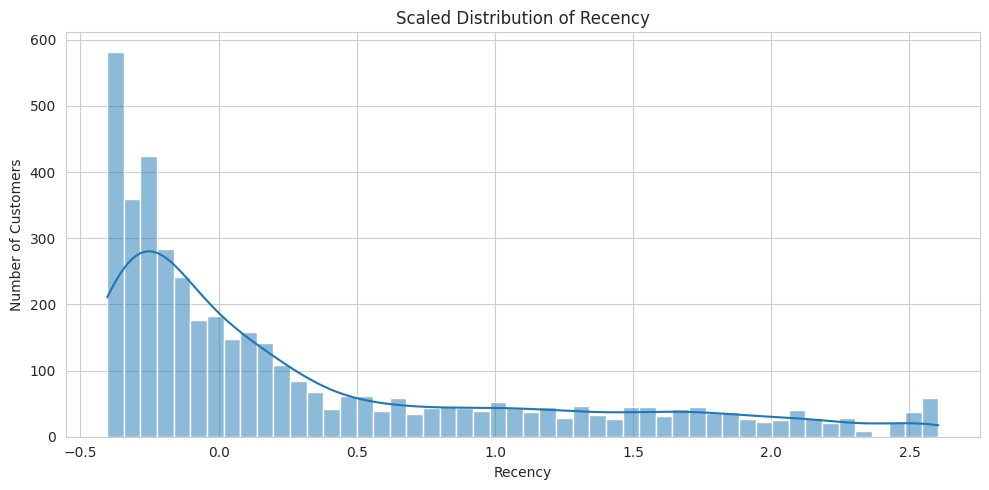

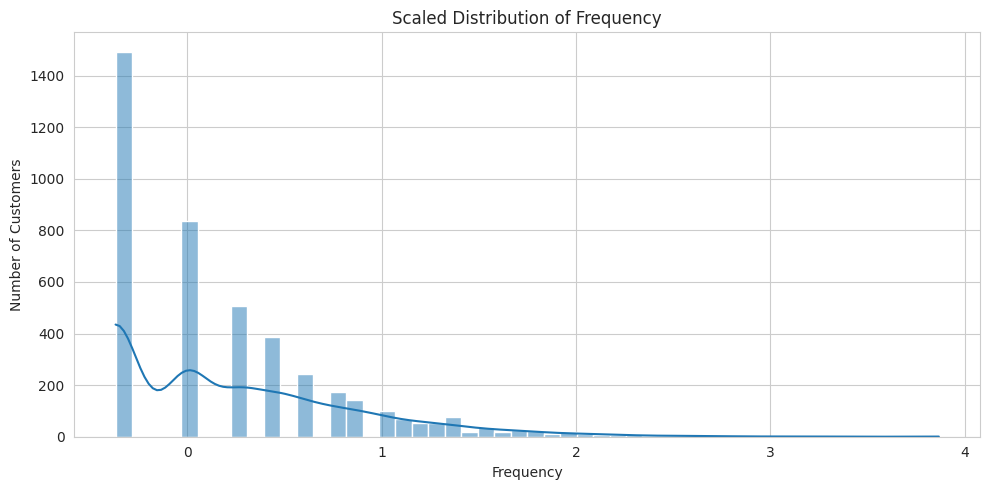

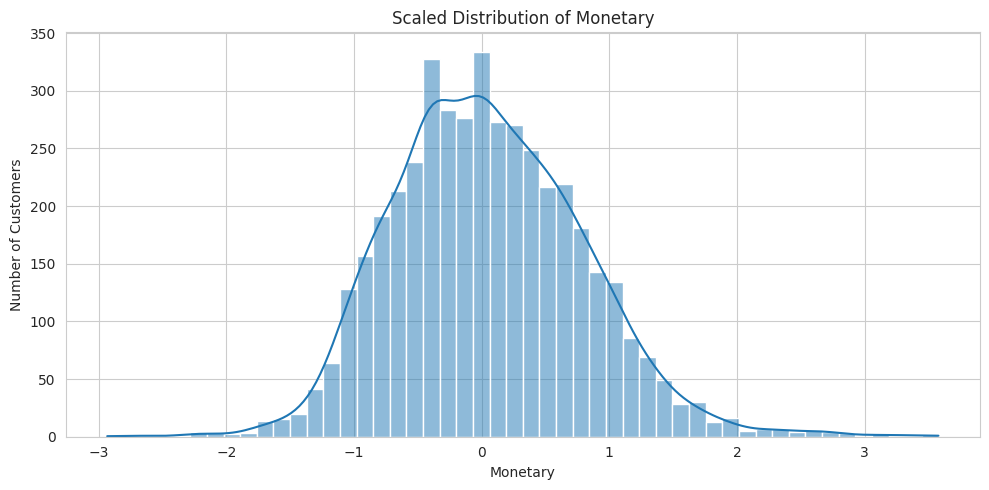

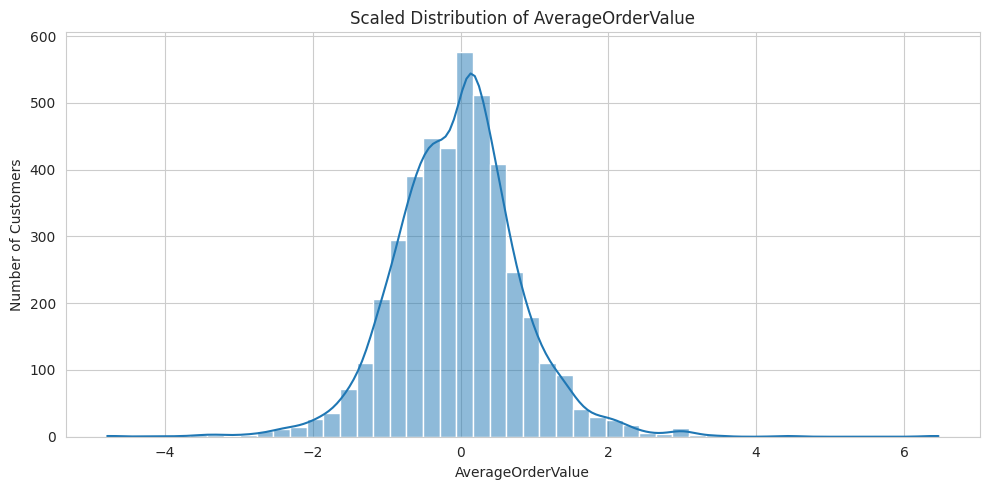

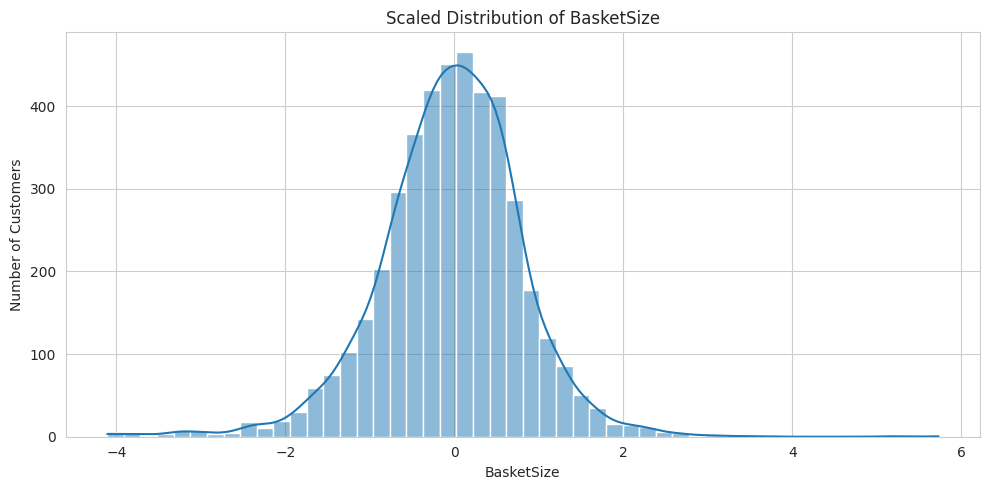

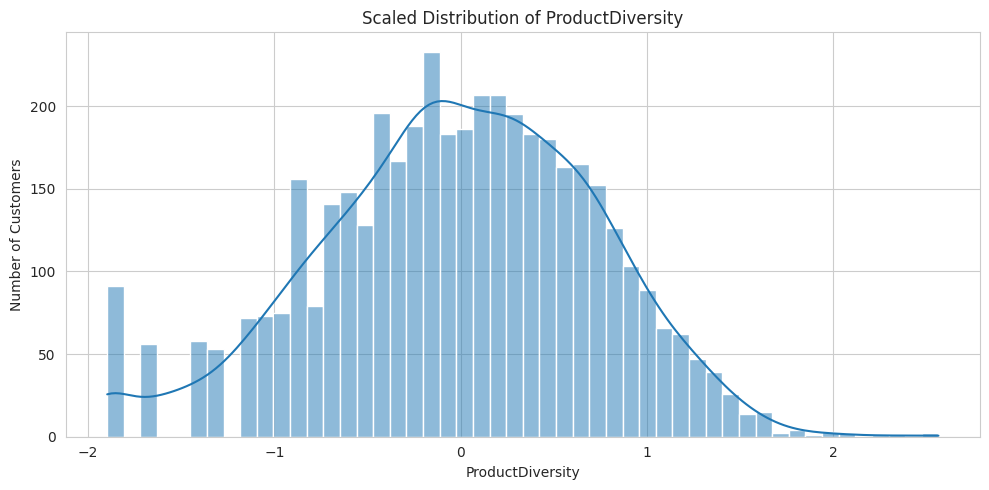

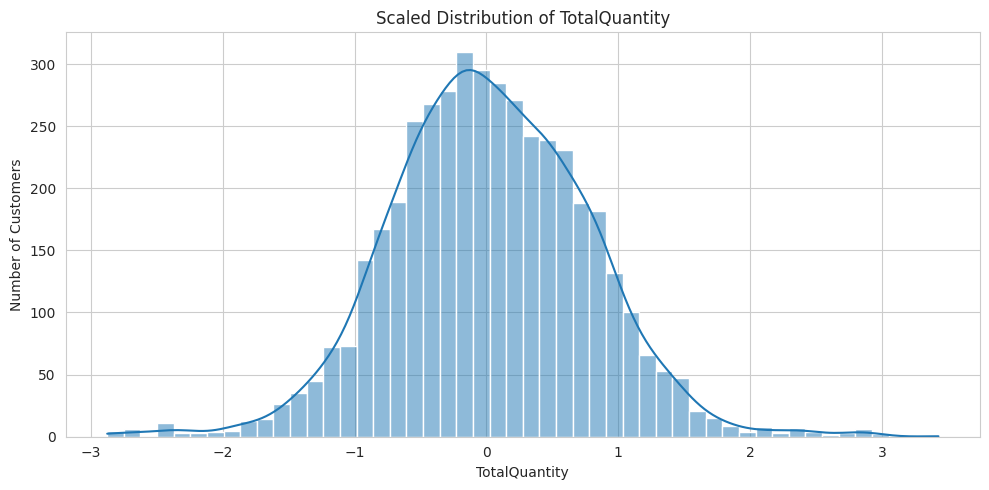

In [26]:
for feature in feature_columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        processed_features[feature],
        bins=50,
        kde=True
    )

    plt.title(
        f"Scaled Distribution of {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Customers")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            figures_dir,
            f"scaled_distribution_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


###  27: Recheck correlation after scaling




Scaled feature correlation matrix:


,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
Recency,1.0000,-0.4728,-0.4342,-0.1386,-0.1968,-0.4184,-0.4527
Frequency,-0.4728,1.0000,0.8081,0.1643,0.1527,0.6227,0.7525
Monetary,-0.4342,0.8081,1.0000,0.7089,0.5902,0.6924,0.9217
AverageOrderValue,-0.1386,0.1643,0.7089,1.0000,0.8104,0.4030,0.6422
BasketSize,-0.1968,0.1527,0.5902,0.8104,1.0000,0.4323,0.7621
ProductDiversity,-0.4184,0.6227,0.6924,0.4030,0.4323,1.0000,0.7017
TotalQuantity,-0.4527,0.7525,0.9217,0.6422,0.7621,0.7017,1.0000


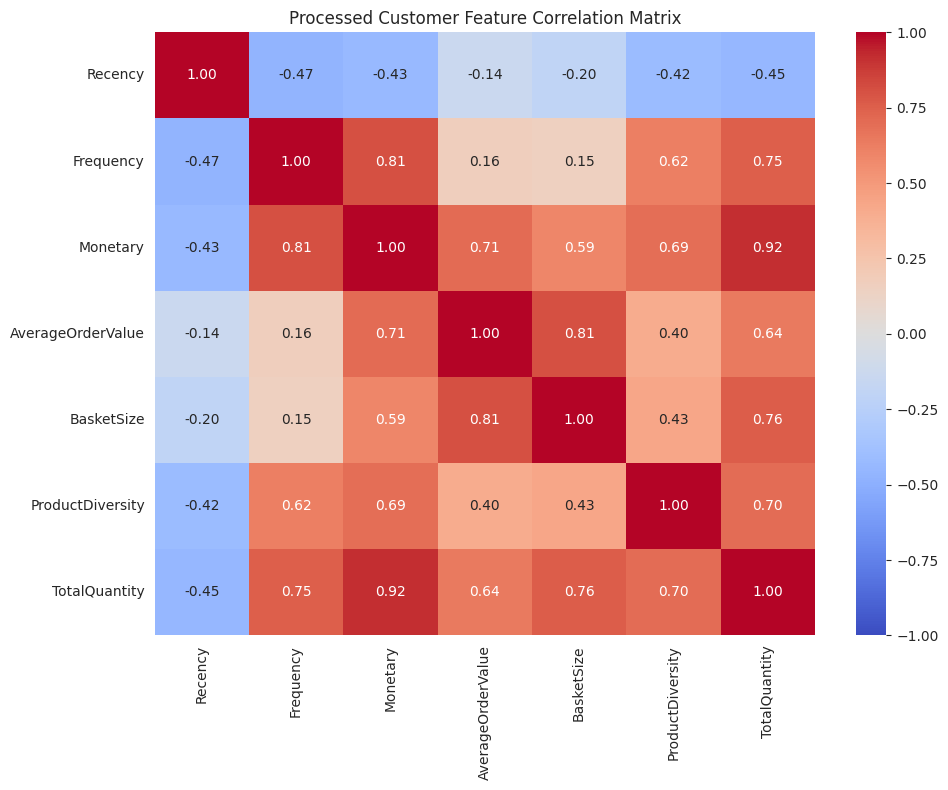

In [27]:
scaled_correlation_matrix = (
    processed_features[feature_columns]
    .corr(method="pearson")
)

print("\nScaled feature correlation matrix:")
display(scaled_correlation_matrix)

scaled_correlation_matrix.to_csv(
    os.path.join(
        tables_dir,
        "scaled_feature_correlation_matrix.csv"
    )
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    scaled_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title(
    "Processed Customer Feature Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "processed_feature_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  28: Check for near-zero variance


In [28]:
processed_variance_report = pd.DataFrame({
    "Feature": feature_columns,

    "Variance": [
        processed_features[feature].var()
        for feature in feature_columns
    ],

    "Unique Values": [
        processed_features[feature].nunique()
        for feature in feature_columns
    ]
})

processed_variance_report[
    "Near Zero Variance"
] = (
    processed_variance_report[
        "Variance"
    ] < 0.01
)

print("\nProcessed feature variance report:")
display(processed_variance_report)

processed_variance_report.to_csv(
    os.path.join(
        tables_dir,
        "processed_feature_variance_report.csv"
    ),
    index=False
)



Processed feature variance report:


,Feature,Variance,Unique Values,Near Zero Variance
0,Recency,0.6505,349,False
1,Frequency,0.3866,59,False
2,Monetary,0.5564,4240,False
3,AverageOrderValue,0.7252,4147,False
4,BasketSize,0.7140,2129,False
5,ProductDiversity,0.5517,338,False
6,TotalQuantity,0.5651,1749,False


## Phase 5: Exploratory PCA and final validation



###  29: Create a two-dimensional PCA view





PCA explained variance:


,Principal Component,Explained Variance Ratio,Explained Variance Percentage
0,PC1,0.6156,61.5640
1,PC2,0.1980,19.8007


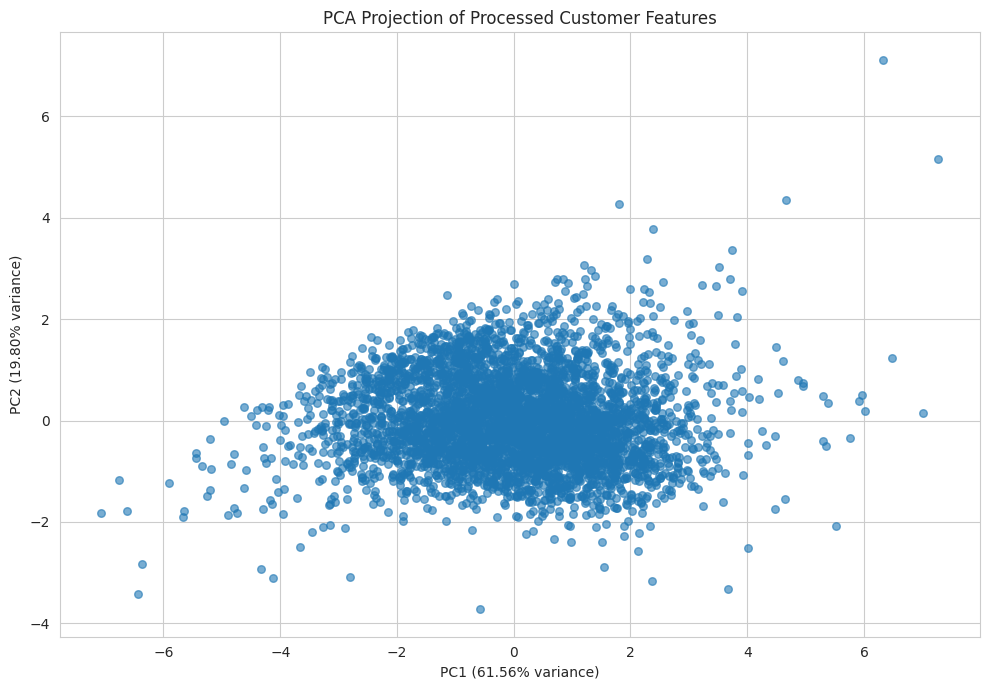

In [29]:
# PCA IS NOT USED AS THE CLUSTERING INPUT

pca = PCA(
    n_components=2,
    random_state=42
)

pca_coordinates = pca.fit_transform(
    processed_features[feature_columns]
)

pca_dataframe = pd.DataFrame({
    "CustomerID":
        processed_features["CustomerID"],

    "PC1":
        pca_coordinates[:, 0],

    "PC2":
        pca_coordinates[:, 1]
})

pca_variance_report = pd.DataFrame({
    "Principal Component": [
        "PC1",
        "PC2"
    ],

    "Explained Variance Ratio":
        pca.explained_variance_ratio_,

    "Explained Variance Percentage":
        pca.explained_variance_ratio_
        * 100
})

print("\nPCA explained variance:")
display(pca_variance_report)

pca_variance_report.to_csv(
    os.path.join(
        tables_dir,
        "pca_explained_variance_report.csv"
    ),
    index=False
)

pca_dataframe.to_csv(
    os.path.join(
        data_dir,
        "customer_features_pca_visualisation.csv"
    ),
    index=False
)

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_dataframe["PC1"],
    pca_dataframe["PC2"],
    alpha=0.60,
    s=30
)

plt.title(
    "PCA Projection of Processed Customer Features"
)

plt.xlabel(
    f"PC1 "
    f"({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 "
    f"({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "pca_projection_before_clustering.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  30: Validate the final processed dataset



In [30]:
expected_column_order = [
    "CustomerID"
] + feature_columns

processed_features = processed_features[
    expected_column_order
].copy()

final_validation_report = pd.DataFrame({
    "Validation Check": [
        "Expected columns present",
        "TransactionCount removed",
        "Missing values",
        "Duplicate Customer IDs",
        "Infinite values",
        "Constant features",
        "Near-zero variance features",
        "Customer count unchanged",
        "Ready for clustering"
    ],

    "Result": [
        list(processed_features.columns)
        == expected_column_order,

        "TransactionCount"
        not in processed_features.columns,

        processed_features
        .isnull()
        .sum()
        .sum(),

        processed_features[
            "CustomerID"
        ]
        .duplicated()
        .sum(),

        np.isinf(
            processed_features[
                feature_columns
            ]
            .to_numpy()
        )
        .sum(),

        len(
            processed_variance_report.loc[
                processed_variance_report[
                    "Unique Values"
                ] <= 1
            ]
        ),

        len(
            processed_variance_report.loc[
                processed_variance_report[
                    "Near Zero Variance"
                ]
            ]
        ),

        len(processed_features)
        == len(customer_features),

        "YES"
    ]
})

print("\nFinal preprocessing validation report:")
display(final_validation_report)

final_validation_report.to_csv(
    os.path.join(
        tables_dir,
        "final_preprocessing_validation_report.csv"
    ),
    index=False
)



Final preprocessing validation report:


,Validation Check,Result
0,Expected columns present,True
1,TransactionCount removed,True
2,Missing values,0
3,Duplicate Customer IDs,0
4,Infinite values,0
5,Constant features,0
6,Near-zero variance features,0
7,Customer count unchanged,True
8,Ready for clustering,YES


###  31: Run final assertion checks




In [31]:
assert list(
    processed_features.columns
) == expected_column_order

assert (
    "TransactionCount"
    not in processed_features.columns
)

assert (
    processed_features
    .isnull()
    .sum()
    .sum()
    == 0
)

assert (
    processed_features[
        "CustomerID"
    ]
    .duplicated()
    .sum()
    == 0
)

assert np.isfinite(
    processed_features[
        feature_columns
    ]
    .to_numpy()
).all()

assert (
    len(processed_features)
    == len(customer_features)
)

print(
    "\nAll final preprocessing validation checks passed."
)



All final preprocessing validation checks passed.


###  32: Export the processed clustering dataset




In [32]:
processed_output_path = os.path.join(
    data_dir,
    "customer_features_processed.csv"
)

processed_features.to_csv(
    processed_output_path,
    index=False
)

print("\nFinal processed dataset saved successfully.")

print("\nOutput path:")
print(processed_output_path)

print("\nFinal processed dataset shape:")
print(processed_features.shape)

print("\nFinal processed columns:")
print(processed_features.columns.tolist())

display(processed_features.head())



Final processed dataset saved successfully.

Output path:
/content/Advanced_Preprocessing_Results/Data/customer_features_processed.csv

Final processed dataset shape:
(4338, 8)

Final processed columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,12346,2.2177,-0.3691,2.8139,6.3667,5.7289,-1.8972,2.8943
1,12347,-0.3952,0.8928,1.1038,0.8503,0.7260,0.6963,1.0256
2,12348,0.1935,0.4650,0.5856,0.4911,1.2025,-0.2941,0.9989
3,12349,-0.2581,-0.3691,0.5723,2.0472,1.2728,0.4730,0.2805
4,12350,2.0887,-0.3691,-0.4098,0.1546,0.1876,-0.4550,-0.3561


###  33: Create a preprocessing summary



In [33]:
preprocessing_summary = pd.DataFrame({
    "Stage": [
        "Input Dataset",
        "Remove Unused Features",
        "Raw Validation",
        "Distribution Assessment",
        "Outlier Analysis",
        "Correlation Analysis",
        "Variance Analysis",
        "Log Transformation",
        "VIF Analysis",
        "Robust Scaling",
        "Scaling Verification",
        "PCA Visualisation",
        "Final Validation",
        "Export"
    ],

    "Status": [
        "Completed",
        "Completed",
        "Passed",
        "Completed",
        "Completed - Outliers Retained",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Passed",
        "Completed - Visualisation Only",
        "Passed",
        "Completed"
    ],

    "Details": [
        str(customer_features_original.shape),
        str(unexpected_columns),
        "No missing, duplicate or invalid values",
        "Skewness, kurtosis, histograms and boxplots",
        "IQR method used; genuine customers retained",
        f"Threshold = {correlation_threshold}",
        "Constant and near-zero variance checks",
        str(log_features),
        "Multicollinearity assessed after transformation",
        "All seven clustering features scaled",
        "Median and IQR checked",
        "Two principal components generated",
        "Dataset confirmed ready for clustering",
        processed_output_path
    ]
})

print("\nPreprocessing pipeline summary:")
display(preprocessing_summary)

preprocessing_summary.to_csv(
    os.path.join(
        tables_dir,
        "advanced_preprocessing_summary.csv"
    ),
    index=False
)



Preprocessing pipeline summary:


,Stage,Status,Details
0,Input Dataset,Completed,"(4338, 9)"
1,Remove Unused Features,Completed,['TransactionCount']
2,Raw Validation,Passed,"No missing, duplicate or invalid values"
3,Distribution Assessment,Completed,"Skewness, kurtosis, histograms and boxplots"
4,Outlier Analysis,Completed - Outliers Retained,IQR method used; genuine customers retained
5,Correlation Analysis,Completed,Threshold = 0.9
6,Variance Analysis,Completed,Constant and near-zero variance checks
7,Log Transformation,Completed,"['Frequency', 'Monetary', 'AverageOrderValue',..."
8,VIF Analysis,Completed,Multicollinearity assessed after transformation
9,Robust Scaling,Completed,All seven clustering features scaled


###  34: Display the completion summary




In [35]:

print("ADVANCED PREPROCESSING COMPLETED SUCCESSFULLY")


print("\nFinal clustering features:")

for feature in feature_columns:
    print(f"- {feature}")

print("\nTransactionCount was removed.")

print("\nOutliers were analysed but retained.")

print("\nLog transformation was applied to:")
print(log_features)

print("\nRobust scaling was applied to all clustering features.")

print("\nThe processed dataset is ready for K-Means clustering.")

print("\nMain output file:")
print(processed_output_path)


ADVANCED PREPROCESSING COMPLETED SUCCESSFULLY

Final clustering features:
- Recency
- Frequency
- Monetary
- AverageOrderValue
- BasketSize
- ProductDiversity
- TotalQuantity

TransactionCount was removed.

Outliers were analysed but retained.

Log transformation was applied to:
['Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']

Robust scaling was applied to all clustering features.

The processed dataset is ready for K-Means clustering.

Main output file:
/content/Advanced_Preprocessing_Results/Data/customer_features_processed.csv
